# Gene Expression Explorer

## Overview

A small bioinformatics data-analysis project using SQLite, SQL, and Python
to explore gene expression differences between control and disease samples.

## Tools
- SQLite
- SQL
- Python
- pandas
- matplotlib

## Analysis
- Relational database design
- SQL JOINs
- Missing-value handling
- Conditional aggregation
- Disease/control expression averages
- Fold-change calculation
- Ranking
- Data visualization

# 1. Load data

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("gene_results.csv")

# 2. Explore the dataset

In [3]:
df.head()

,gene_name,control_avg,control_n,disease_avg,disease_n,difference,fold_change,fold_change_rank
0,CDK2,9.8,1,42.95,2,33.15,4.382653,1
1,KRAS,10.2,1,40.60,2,30.40,3.980392,2
2,TP53,12.4,1,48.55,2,36.15,3.915323,3
3,AKT1,16.2,1,50.35,2,34.15,3.108025,4
4,MYC,20.1,1,59.50,2,39.40,2.960199,5


In [4]:
df.columns

Index(['gene_name', 'control_avg', 'control_n', 'disease_avg', 'disease_n',
       'difference', 'fold_change', 'fold_change_rank'],
      dtype='object')

In [5]:
df.shape

(9, 8)

# 3. Visualize average expression

In [6]:
import matplotlib.pyplot as plt

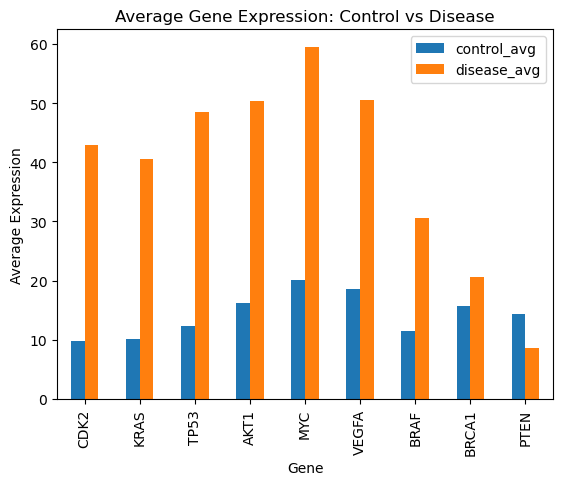

In [8]:
df.plot(
    x="gene_name",
    y=["control_avg","disease_avg"],
    kind="bar"
)
plt.title("Average Gene Expression: Control vs Disease")
plt.xlabel("Gene")
plt.ylabel("Average Expression")
plt.show()

# 4. Analyze fold change

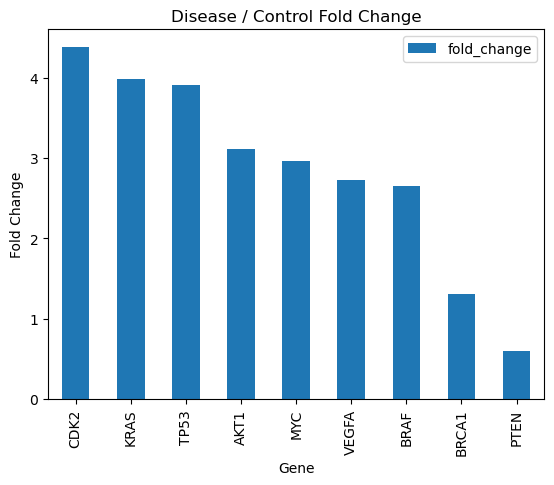

In [9]:
df.plot(
    x="gene_name",
    y="fold_change",
    kind="bar"
)

plt.title("Disease / Control Fold Change")
plt.xlabel("Gene")
plt.ylabel("Fold Change")

plt.show()

In [10]:
df.loc[df["fold_change"].idxmax()]

gene_name               CDK2
control_avg              9.8
control_n                  1
disease_avg            42.95
disease_n                  2
difference             33.15
fold_change         4.382653
fold_change_rank           1
Name: 0, dtype: object

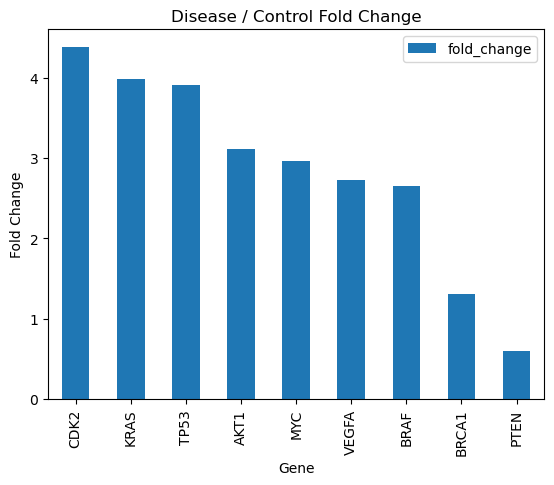

In [13]:
df_sorted = df.sort_values("fold_change", ascending=False)

df_sorted.plot(
    x="gene_name",
    y="fold_change",
    kind="bar"
)

plt.title("Disease / Control Fold Change")
plt.xlabel("Gene")
plt.ylabel("Fold Change")

plt.show()

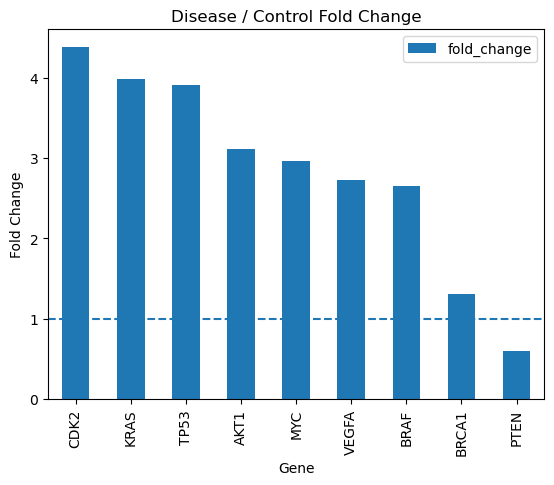

In [14]:
df_sorted.plot(
    x="gene_name",
    y="fold_change",
    kind="bar"
)

plt.axhline(y=1, linestyle="--")

plt.title("Disease / Control Fold Change")
plt.xlabel("Gene")
plt.ylabel("Fold Change")

plt.show()

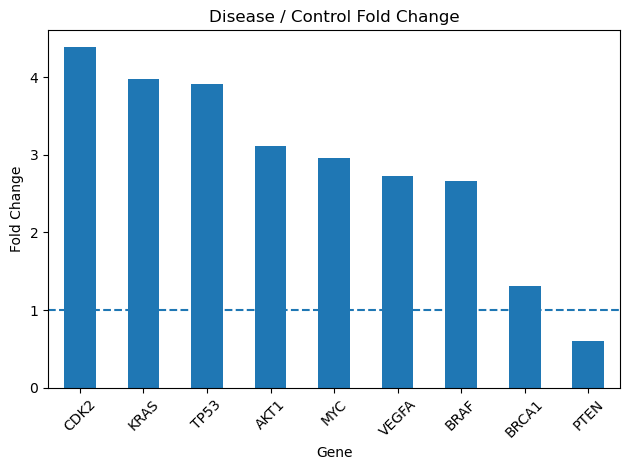

In [15]:
df_sorted.plot(
    x="gene_name",
    y="fold_change",
    kind="bar",
    legend=False
)

plt.axhline(y=1, linestyle="--")

plt.title("Disease / Control Fold Change")
plt.xlabel("Gene")
plt.ylabel("Fold Change")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [16]:
df_sorted[[
    "gene_name",
    "control_avg",
    "disease_avg",
    "difference",
    "fold_change"
]]

,gene_name,control_avg,disease_avg,difference,fold_change
0,CDK2,9.8,42.95,33.15,4.382653
1,KRAS,10.2,40.60,30.40,3.980392
2,TP53,12.4,48.55,36.15,3.915323
3,AKT1,16.2,50.35,34.15,3.108025
4,MYC,20.1,59.50,39.40,2.960199
5,VEGFA,18.6,50.60,32.00,2.720430
6,BRAF,11.5,30.55,19.05,2.656522
7,BRCA1,15.7,20.60,4.90,1.312102
8,PTEN,14.3,8.55,-5.75,0.597902


In [17]:
df_sorted.head(3)

,gene_name,control_avg,control_n,disease_avg,disease_n,difference,fold_change,fold_change_rank
0,CDK2,9.8,1,42.95,2,33.15,4.382653,1
1,KRAS,10.2,1,40.60,2,30.40,3.980392,2
2,TP53,12.4,1,48.55,2,36.15,3.915323,3


# 5. Results

The dataset was analyzed using SQL to calculate average gene expression in control and disease samples. Disease-to-control fold change was then calculated for each gene with at least two available disease measurements.

Among the genes that passed this filtering criterion, CDK2 showed the highest disease/control fold change in this dataset. Several other genes also showed higher average expression in disease samples, while PTEN showed lower average expression in disease samples compared with control.

The results were visualized in Python using pandas and matplotlib, allowing comparison of average expression between conditions and visualization of disease/control fold changes.

# Key Findings

- CDK2 had the highest disease/control fold change among the filtered genes.
- PTEN showed lower average expression in disease samples than in control samples.
- EGFR had a missing disease measurement, which was handled as NULL rather than zero.
- Genes were filtered based on the number of available disease measurements.

# Limitations

This project uses a small, illustrative dataset designed for learning SQL and Python rather than for drawing biological conclusions. The number of samples is too small for robust statistical inference, and the analysis does not include biological replicates, normalization procedures, or formal differential-expression testing.

Therefore, fold changes in this project should be interpreted as descriptive measurements rather than evidence of statistically significant differential expression.

A real RNA-seq analysis would require an appropriate experimental design, quality control, normalization, replicate-aware statistical analysis, and tools such as DESeq2 or edgeR.